## Module 4:

## Team Members:
Sara Elster, Lauren Kim

## Project Title:
Evaluating the Effects of Cancer Hallmarks on Tumor Growth and Resilience


## Project Goal:

This project seeks to answer the following questions about the relationships between and effects of cancer hallmarks on tumor growth:

1. Are sustained growth signals related to evasion of growth suppression in lung cancer?
    
2. Does expression of both growth signals and evasion of growth suppression correlate to tumor stage?


## Disease Background:

### Cancer Hallmark 1: Sustained Growth Signals
#### Overview of Hallmark
Sustained growth signaling refers to the ability of cancer cells to continuously proliferate without the normal external signals required for cell division by producing their own growth signals (autocrine signaling), overexpressing growth factor receptors, or activating downstream signaling pathways constitutively. This leads to uncontrolled cell division and tumor progression.

#### Genes Associated with Hallmark to be Studied
Key genes involved in sustained growth signaling are typically part of major proliferative pathways such as the RTK/RAS/MAPK and PI3K/AKT/mTOR pathways. Genes of interest include:

* EGFR – encodes a receptor tyrosine kinase that, when overactivated, drives proliferation
* KRAS – a GTPase that transduces growth signals; commonly mutated in cancers
* BRAF – downstream of RAS, activates MAPK signaling
* PIK3CA – catalytic subunit of PI3K, promotes cell growth and survival
* AKT1 – central kinase in survival and growth signaling
* MYC – transcription factor that regulates genes involved in proliferation

**See genes_of_interest.csv for more information on key genes.**

### Cancer Hallmark 2: Evading Growth Suppressors
#### Overview of Hallmark
Evading growth suppressors refers to the ability of cancer cells to bypass mechanisms that inhibit cell proliferation by disabling these tumor suppressor pathways, which normally act as checkpoints to prevent uncontrolled division, repaire DNA damage, and trigger apoptosis. Without these pathways, cancer cells can proliferate despite cellular damage or unfavorable conditions.

#### Genes Associated with Hallmark to be Studied
Key genes involved in evasion of growth suppressors include tumor suppressor genes and cell cycle regulators. Genes of interest include:

* TP53 – encodes p53, a critical regulator of DNA damage response and apoptosis
* RB1 – controls the G1/S checkpoint of the cell cycle
* CDKN2A – encodes p16, an inhibitor of cyclin-dependent kinases
* PTEN – negatively regulates the PI3K/AKT pathway
* SMAD4 – involved in TGF-β signaling, which suppresses proliferation
* APC – regulates β-catenin and Wnt signaling, preventing uncontrolled growth

### Cancer Hallmark 3: Phenotypic Plasticity
#### Overview of Hallmark
Just as the term implies phenotypic plasticity refers to a cancer cell’s ability to transition between various cellular states. Because they lack a definite diffrentiation, this cancer hallmark enables cancerous cells to assume a functionality that more closely aligns with that of a stem cell. Being less differentiated (specialized) allows for other functions such as sustained proliferation and the capacity to take on different phenotypic characteristics. This not only sustains the cancer cell but also allows them to become more adaptable to various environments via metabolic reprogramming and epthelial-mesenchymal transition. When working in concert with one another, these enabled functions give tumours power to resist treatment or therapies designed to combat cancerous cells. 

#### Genes Associated with Hallmark to be Studied
Key genes involved in phenotypic plasticity are typically part of cellular pathways such as epithelial-mesenchymal transition (EMT). 

Genes of interest include:
* Twist - regulates gene expression related to epithelial and mesenchymal features. 
* Snail - regulates gene expression related to epithelial and mesenchymal features. 
* Slug - regulates gene expression related to epithelial and mesenchymal features. 
* ZEB1 - regulates gene expression related to epithelial and mesenchymal features. 

**See genes_of_interest.csv for more information on key genes.**



### Cancer Types
#### Lung Adenocarcinoma
**Prevalence & incidence**

The World Health Organization reports ~2.2 million new cases and 1.8 million deaths globally per year. In the U.S., the American Cancer Society estimates ~238,000 new cases annually.

**Risk Factors**
* Lifestyle: Smoking
* Environmental: Radon, air pollution, asbestos
* Genetic: Mutations, family history
* Societal: Lower socioeconomic status, limited screening access, healthcare disparities

**Standard of Care Treatments**
* Surgery
* Radiation & chemotherapy
* Targeted therapy
* Immunotherapy

**Biological Mechanism**

Lung cancer is caused by uncontrolled cell growth in lung tissue. Mutations in oncogenes (EGFR, KRAS) drive proliferation, and loss of tumor suppressors (TP53) removes growth control, which leads to tumor formation, invasion, and metastasis.

## Data-Set: 

The raw dataset was provided by Dr. Groves and was entitled, "TRAINING_SET_GSE62944_subsample_log2TPM.csv". Of the raw data, we elected to focus on Lung Adenocarcinoma and filter the dataset for genes of interest related to the hallmarks of sustained growth signals, evading growht suppressors, and phenotypic plascticity. 

In [1]:
# Exploratory data analysis (EDA) on a cancer dataset
# Loading the files and exploring the data with pandas
# %%
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# %%
# Load the data
####################################################
data = pd.read_csv(
    '../Data/TRAINING_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)  # can also use larger dataset with more genes
metadata_df = pd.read_csv(
    '../Data/TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)

## Data Analysis: 



### Part 1: Data Exploration and Dimensionality Reduction

After loading the raw dataset as described above, the data was filtered to append only LUAD data to a list. 

In [2]:
cancer_type = 'LUAD'  # Lung Adenocarcinoma

# From metadata, get the rows where "cancer_type" is equal to the specified cancer type
# Then grab the index of this subset (these are the sample IDs)
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
# Subset the main data to include only these samples
# When you want a subset of columns, you can pass a list of column names to the data frame in []
LUAD_data = data[cancer_samples]

The subsequent step was to filter the newly formed LUAD dataset for the specified genes of interest (selection criteria was based on gene association with the hallmarks of sustained growth factors and evading growth suppression). We ended up using six genes for each hallmark, giving twelve genes total.

In [3]:
sustained_growth_genes = ['EGFR','KRAS','BRAF','PIK3CA','AKT1', 'MYC']
evade_growth_suppression_genes = ['TP53','RB1','CDKN2A','PTEN','SMAD4','APC']
total_growth_genes = ['EGFR','KRAS','BRAF','PIK3CA','AKT1', 'MYC','TP53','RB1','CDKN2A','PTEN','SMAD4','APC']

# .loc[] is the method to subset by index labels
# .iloc[] will subset by index position (integer location) instead
LUAD_sustained_growth_data = LUAD_data.loc[sustained_growth_genes]
LUAD_evade_suppression_data = LUAD_data.loc[evade_growth_suppression_genes]
LUAD_gene_data = LUAD_data.loc[total_growth_genes]



The next step was to explore the dataset within a certain category, pathologic tumor stage, and then within the subcategory, filter and calculate the mean age at diagnosis.

In [4]:
#explore dataset by gender
print(metadata_df.groupby('cancer_type')["ajcc_pathologic_tumor_stage"].value_counts())

# Merging datasets
####################################################

LUAD_metadata = metadata_df.loc[cancer_samples]
LUAD_merged = LUAD_gene_data.T.merge(
    LUAD_metadata, left_index=True, right_index=True)
print(LUAD_merged.head())

cancer_type  ajcc_pathologic_tumor_stage
ACC          Stage II                       37
             Stage III                      16
             Stage IV                       15
             Stage I                         9
             [Not Available]                 2
                                            ..
THCA         Stage I                        41
             Stage III                      19
             Stage II                       13
             Stage IVA                       4
             [Not Available]                 2
Name: count, Length: 114, dtype: int64
                                  EGFR      KRAS      BRAF    PIK3CA  \
TCGA-44-8117-01A-11R-2241-07  5.948056  5.564254  3.107750  3.556841   
TCGA-50-5936-01A-11R-1628-07  4.908641  5.501215  2.322553  4.308947   
TCGA-55-A494-01A-11R-A24X-07  5.058511  6.517595  2.956489  3.850032   
TCGA-78-7160-01A-11R-2039-07  3.980713  5.480804  2.371141  4.433824   
TCGA-78-7158-01A-11R-2039-07  4.651723  4.8

A PCA was performed to view the variance in expression of genes in both female and male patients of LUAD samples.

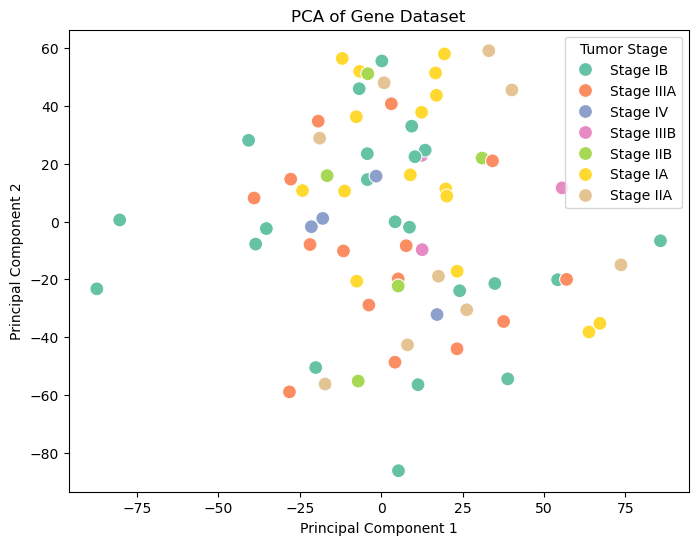

In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.decomposition import PCA

# AI was utilized to debug errors

# Complete a PCA of the subsetted gene data
X = LUAD_data.T

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0],
                y=X_pca[:, 1],
                hue = LUAD_merged['ajcc_pathologic_tumor_stage'], # Observe the variance in both male and female patients 
        
        
                palette="Set2",
                s=100)
plt.title("PCA of Gene Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Tumor Stage")
plt.show()


Next, K-Means was utilized to observe whether centroids could accurately locate clusters. 

c:\Users\crown\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


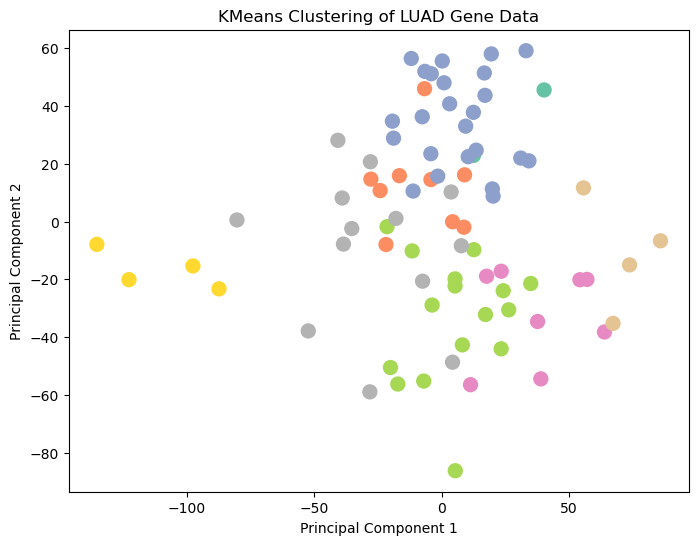

In [6]:
# KMeans Clustering

model = KMeans(random_state=0)
model.fit(X)
y_kmeans = model.predict(X)
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap="Set2", s=100)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clustering of LUAD Gene Data")

plt.show()

Hierarchial Clustering was utilized to view relationship linkages between genes of the subset. 

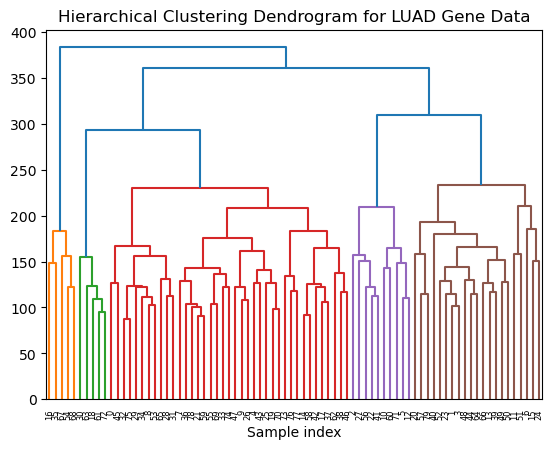

In [7]:
# Hierarchical Clustering

import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_iris


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(X)
plt.title("Hierarchical Clustering Dendrogram for LUAD Gene Data")
# plot the top three levels of the dendrogram
plot_dendrogram(model)
plt.xlabel("Sample index")
plt.show()

DBSCAN was used to identify clusters based on the defined epsilon value ($\epsilon$ = 2). 

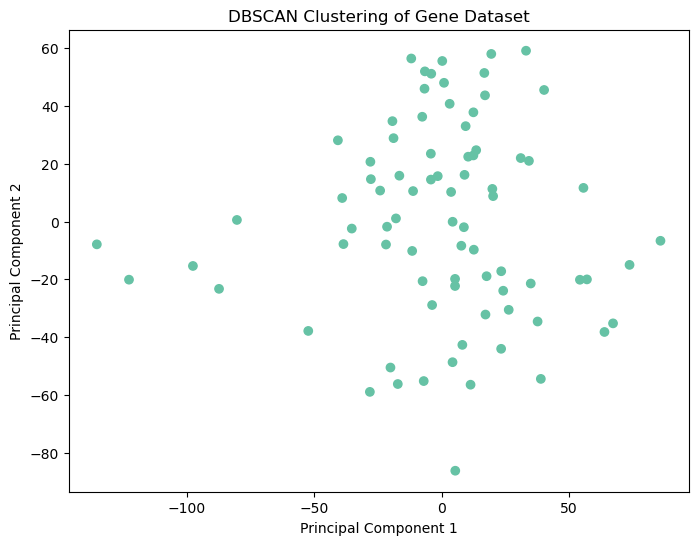

In [8]:
# use DBSCAN to cluster the gene data
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps= 2, min_samples=5)
y_dbscan = dbscan.fit_predict(X)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_dbscan, cmap="Set2")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clustering of Gene Dataset")
plt.show()

UMAP was used as a non-linear dimension reduction technique to re-visualize the gene subset on a 2-Dimensional scale.

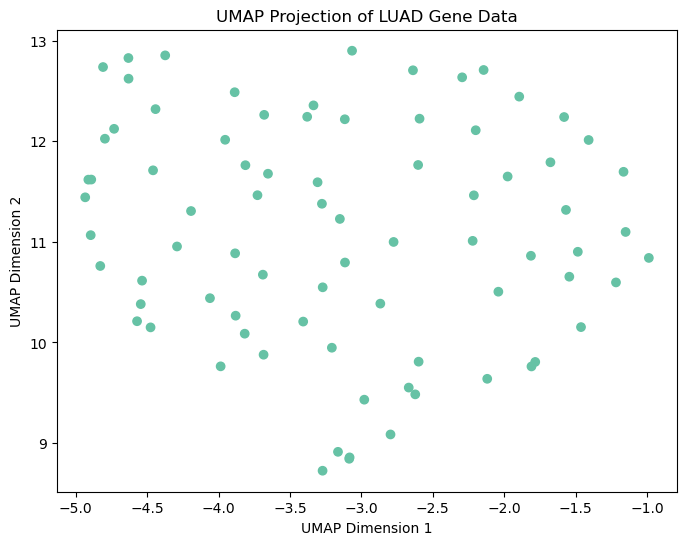

In [9]:
from sklearn.preprocessing import StandardScaler
import umap

scaled_data = StandardScaler().fit_transform(X)

reducer = umap.UMAP()
X_umap = reducer.fit_transform(scaled_data)
y_dbscan = dbscan.fit_predict(X_umap)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_dbscan, cmap="Set2")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of LUAD Gene Data")
plt.show()

### Part 2: Supervised Maching Learning Model - Linear Regression Comparing Sustained Growth Signal Genes with Evading Growth Supression Genes

For our supervised machine learning model, we used a linear regression to compare expression of sustained growth signal genes with evading growth suppression genes to analyze the relationship between the two hallmarks.

C:\Users\crown\AppData\Local\Temp\ipykernel_22448\598599541.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  slope = float(model.coef_[0])
C:\Users\crown\AppData\Local\Temp\ipykernel_22448\598599541.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  intercept = float(model.intercept_)


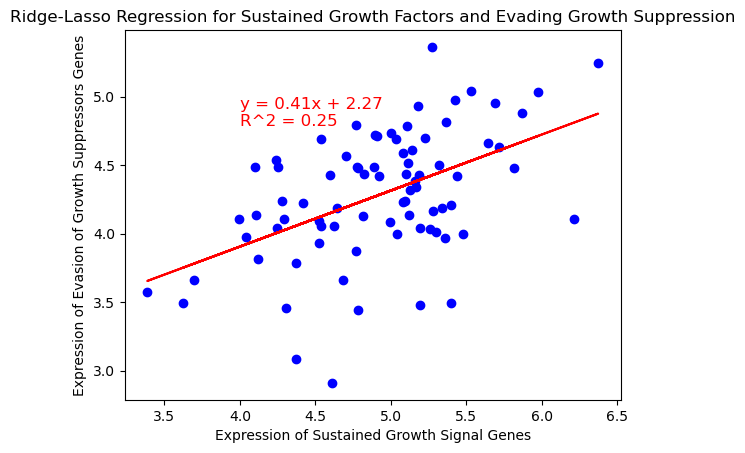

In [26]:
from sklearn.linear_model import LinearRegression

# Taking average of gene expression for each hallmark
growth_mean = LUAD_sustained_growth_data.mean(axis=0)
suppression_mean = LUAD_evade_suppression_data.mean(axis=0)

# Finding common patients
common_patients = growth_mean.index.intersection(suppression_mean.index)

growth_aligned = growth_mean.loc[common_patients]
suppression_aligned = suppression_mean.loc[common_patients]

x_data = np.array(growth_aligned).reshape(-1,1)
y_data = np.array(suppression_aligned).reshape(-1,1)

# Perform Linear Regression
model = LinearRegression()
model.fit(x_data,y_data)

slope = float(model.coef_[0])
intercept = float(model.intercept_)
r2 = model.score(x_data,y_data)

# Creating Equation
equation = f"y = {slope:.2f}x + {intercept:.2f}\nR^2 = {r2:.2f}"
plt.text(4,5, equation, color = "red", fontsize = 12, verticalalignment = "top")

# Scatter plot
plt.scatter(x_data,y_data,color = "blue")
plt.plot(x_data, model.predict(x_data), color = "red")
plt.xlabel("Expression of Sustained Growth Signal Genes")
plt.ylabel("Expression of Evasion of Growth Suppressors Genes")
plt.title("Ridge-Lasso Regression for Sustained Growth Factors and Evading Growth Suppression")
plt.show()

Next, we performed a linear regression comparing tumor stage to mean gene expression of both hallmarks combined.

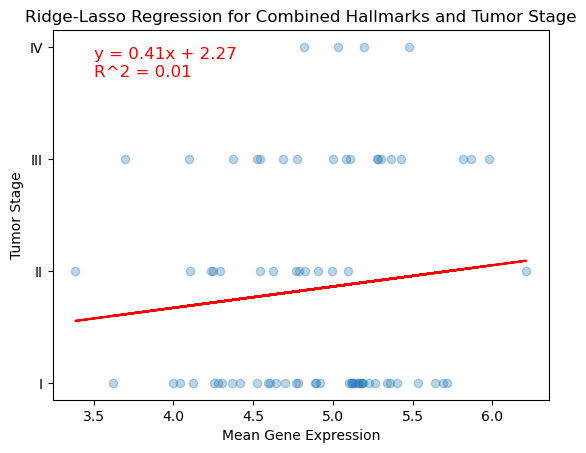

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# ---------------------------
# Fix stage encoding (IMPORTANT FIX)
# ---------------------------
LUAD_merged['stage_num'] = np.nan

stages = LUAD_merged['ajcc_pathologic_tumor_stage'].astype(str)

LUAD_merged.loc[stages.str.contains('Stage I', case=False, na=False), 'stage_num'] = 1
LUAD_merged.loc[stages.str.contains('Stage II', case=False, na=False), 'stage_num'] = 2
LUAD_merged.loc[stages.str.contains('Stage III', case=False, na=False), 'stage_num'] = 3
LUAD_merged.loc[stages.str.contains('Stage IV', case=False, na=False), 'stage_num'] = 4

plot_df = LUAD_merged.dropna(subset=['stage_num'])

# ---------------------------
# X and y
# ---------------------------
x_data = plot_df[sustained_growth_genes].mean(axis=1).values.reshape(-1, 1)
y_data = plot_df['stage_num'].values.reshape(-1, 1)

# ---------------------------
# Scaling (important for Ridge/Lasso)
# ---------------------------
x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_scaled = x_scaler.fit_transform(x_data)
y_scaled = y_scaler.fit_transform(y_data).ravel()

# ---------------------------
# Ridge model
# ---------------------------
model = Ridge(alpha=1.0)
model.fit(x_scaled, y_scaled)

y_pred_scaled = model.predict(x_scaled)

# R^2 (THIS is what you asked for)
r2 = model.score(x_scaled, y_scaled)

# back-transform for plotting
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))

# ---------------------------
# Plot
# ---------------------------
plt.scatter(x_data, y_data, alpha=0.3)
plt.plot(x_data, y_pred, color="red")

plt.yticks([1, 2, 3, 4], ['I', 'II', 'III', 'IV'])
plt.ylabel("Tumor Stage")
plt.xlabel("Mean Gene Expression")

plt.title(f"Ridge-Lasso Regression for Combined Hallmarks and Tumor Stage")
equation = f"y = {slope:.2f}x + {intercept:.2f}\nR^2 = {r2:.2f}"
plt.text(3.5,y_data.max(), equation, color = "red", fontsize = 12, verticalalignment = "top")

plt.show()

### Part 3: Unsupervised Machine Learning Technique - Classification of Tumor Stage by Hallmark Gene Expression

For our unsupervised machine learning model, we used classification by classifying tumor stage by expression of both hallmark-related genes.

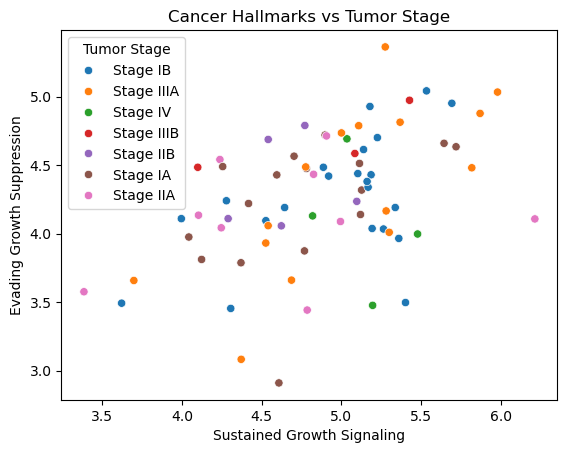

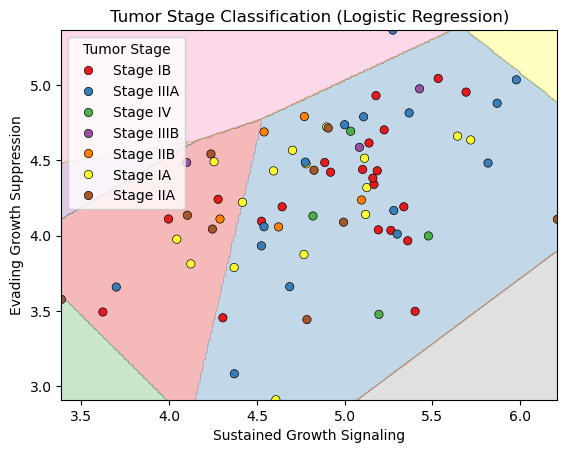

Accuracy: 0.3108108108108108


In [12]:
# Plotting hallmark genes categorized by tumor stage

common_patients_genes = LUAD_metadata.loc[common_patients]
stage_aligned = common_patients_genes['ajcc_pathologic_tumor_stage']

plot_df = pd.DataFrame({
    'growth': growth_aligned,
    'suppression': suppression_aligned,
    'stage': stage_aligned
}).dropna()

plt.figure()
sns.scatterplot(
    data=plot_df,
    x='growth',
    y='suppression',
    hue='stage',
)
plt.xlabel("Sustained Growth Signaling")
plt.ylabel("Evading Growth Suppression")
plt.title("Cancer Hallmarks vs Tumor Stage")
plt.legend(title="Tumor Stage")
plt.show()


# Classification of gene data by tumor stage
# This code was adapted from the in_class_classification.py file with help from AI to predict classification boundaries given more than two categories

# Prepare data
X = plot_df[['growth', 'suppression']].values
y = plot_df['stage']

# Creating labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Fit model
model = LogisticRegression(penalty=None, max_iter=1000)
model.fit(X, y_encoded)

# Create meshgrid
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict regions
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure()

plt.contourf(xx, yy, Z, alpha=0.3, cmap="Set1")

sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    hue=y,
    palette="Set1",
    edgecolor='k'
)

plt.xlabel("Sustained Growth Signaling")
plt.ylabel("Evading Growth Suppression")
plt.title("Tumor Stage Classification (Logistic Regression)")

plt.legend(title="Tumor Stage")
plt.show()

# Evaluate accuracy of model
print("Accuracy:", model.score(X, y_encoded))


### Part 4: Testing Model Performance with Validation Set

Next, we tested our models with a training dataset and compared the $R^2$ scores to the validation set using the exact same subset of genes. 

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# define X as the LUAD merged set of subsetted genes
X = LUAD_merged[total_growth_genes]

# define the target as tumor stage
y = LUAD_merged['ajcc_pathologic_tumor_stage'].astype('category').cat.codes

# train the model using the training dataset
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model utilizing linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# score both the training set and the validation set
train_r2 = model.score(X_train, y_train)
val_r2 = model.score(X_val, y_val)

print("Training R² score:", train_r2)
print("Validation R² score:", val_r2) 

Training R² score: 0.1749403871585412
Validation R² score: -0.06856266825709989


In [ ]:

# define the lists for X and Y
growth_mean = LUAD_sustained_growth_data.mean(axis=0)
suppression_mean = LUAD_evade_suppression_data.mean(axis=0)

# Identify common patients within the list
common_patients = growth_mean.index.intersection(suppression_mean.index)

growth_aligned = growth_mean.loc[common_patients]
suppression_aligned = suppression_mean.loc[common_patients]

# perform machine learning
X = growth_aligned.values.reshape(-1, 1)
y = suppression_aligned.values  # keep 1D

# use the training dataset in order to compare against the validation set
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train using linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# compute R-scores
train_r2 = model.score(X_train, y_train)
val_r2 = model.score(X_val, y_val)

print("Training R² score:", train_r2)
print("Validation R² score:", val_r2)

Training R² score: 0.21957023294453681
Validation R² score: 0.325193835131959


### Part 5: Improving Machine Learning Models

After testing the accuracy of our original models, we modified our three models to improve accuracy.

#### 5a: Linear Regression Comparing Sustained Growth Signal Genes with Evading Growth Supression Genes

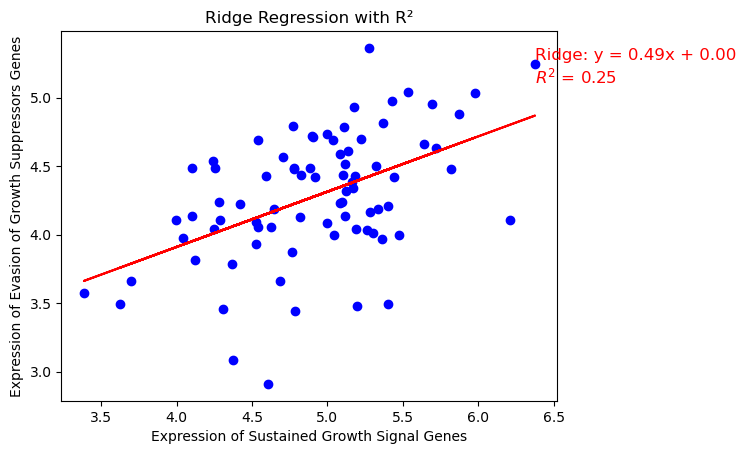

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Taking average of gene expression for each hallmark
growth_mean = LUAD_sustained_growth_data.mean(axis=0)
suppression_mean = LUAD_evade_suppression_data.mean(axis=0)

# Finding common patients
common_patients = growth_mean.index.intersection(suppression_mean.index)

growth_aligned = growth_mean.loc[common_patients]
suppression_aligned = suppression_mean.loc[common_patients]

x_data = np.array(growth_aligned).reshape(-1, 1)
y_data = np.array(suppression_aligned).reshape(-1, 1)

# ---------------------------
# Standardize
# ---------------------------
x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_scaled = x_scaler.fit_transform(x_data)
y_scaled = y_scaler.fit_transform(y_data).ravel()

# ---------------------------
# Ridge Regression
# ---------------------------
model = Ridge(alpha=1.0)
model.fit(x_scaled, y_scaled)

# Predictions
y_pred_scaled = model.predict(x_scaled)

# ---------------------------
# R^2 (IMPORTANT: computed on same space as fit)
# ---------------------------
r2 = model.score(x_scaled, y_scaled)

# ---------------------------
# Back-transform for plotting
# ---------------------------
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))

# Coefficients
slope = model.coef_[0]
intercept = model.intercept_

equation = f"Ridge: y = {slope:.2f}x + {intercept:.2f}\n$R^2$ = {r2:.2f}"

# ---------------------------
# Plot
# ---------------------------
plt.scatter(x_data, y_data, color="blue")
plt.plot(x_data, y_pred, color="red")

plt.xlabel("Expression of Sustained Growth Signal Genes")
plt.ylabel("Expression of Evasion of Growth Suppressors Genes")
plt.title("Ridge Regression with R²")

plt.text(x_data.max(), y_data.max(),
         equation,
         color="red",
         fontsize=12,
         verticalalignment="top")

plt.show()

#### 5b: Linear regression Comparing Tumor Stage to Mean Gene Expression of Both Hallmarks

#### 5c: Classification of Tumor Stage by Hallmark Gene Expression

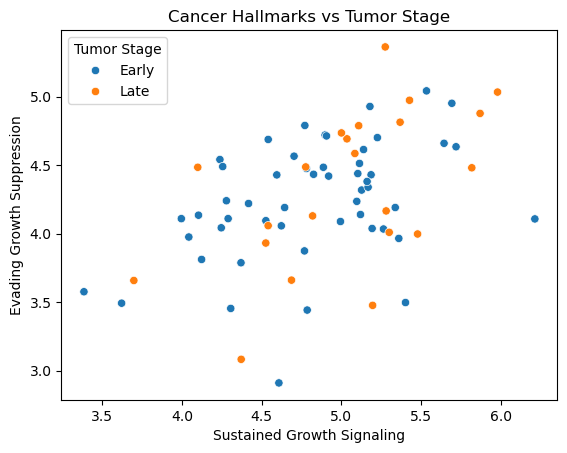

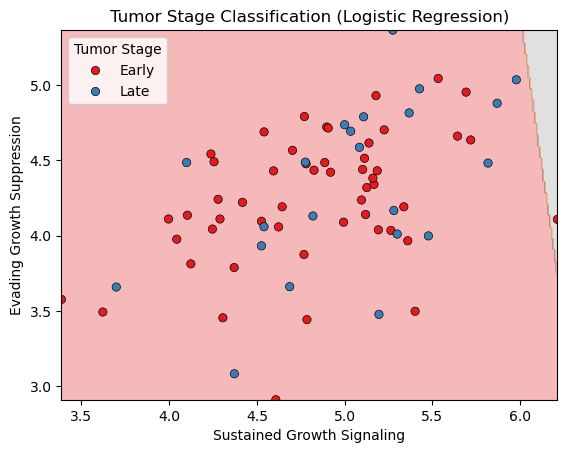

Accuracy: 0.6891891891891891
0.7837837837837838


c:\Users\crown\anaconda3\Lib\site-packages\sklearn\tree\_export.py:386: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  class_name = self.class_names[np.argmax(value)]


[Text(0.5416666666666666, 0.875, 'Evading Growth Suppression <= 4.728\ngini = 0.418\nsamples = 74\nvalue = [52, 22]\nclass = Early'),
 Text(0.3333333333333333, 0.625, 'Evading Growth Suppression <= 4.022\ngini = 0.363\nsamples = 63\nvalue = [48, 15]\nclass = Early'),
 Text(0.4375, 0.75, 'True  '),
 Text(0.16666666666666666, 0.375, 'Evading Growth Suppression <= 3.987\ngini = 0.475\nsamples = 18\nvalue = [11, 7]\nclass = Early'),
 Text(0.08333333333333333, 0.125, 'gini = 0.43\nsamples = 16\nvalue = [11, 5]\nclass = Early'),
 Text(0.25, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]\nclass = Late'),
 Text(0.5, 0.375, 'Evading Growth Suppression <= 4.479\ngini = 0.292\nsamples = 45\nvalue = [37, 8]\nclass = Early'),
 Text(0.4166666666666667, 0.125, 'gini = 0.191\nsamples = 28\nvalue = [25, 3]\nclass = Early'),
 Text(0.5833333333333334, 0.125, 'gini = 0.415\nsamples = 17\nvalue = [12, 5]\nclass = Early'),
 Text(0.75, 0.625, 'Sustained Growth Signaling <= 4.885\ngini = 0.463\nsamples = 11\

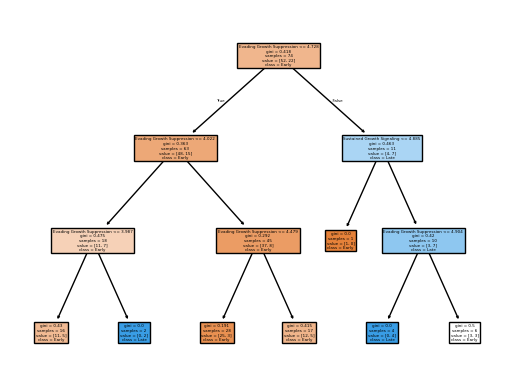

In [14]:
# Classifying AJCC Tumor Stages as Early (Stage I-II) or Late (Stage III-IV)
early_stages = ['Stage 0', 'Stage I', 'Stage IA', 'Stage IB', 'Stage II', 'Stage IIA', 'Stage IIB', 'Stage IIC']
late_stages = ['Stage IIIC', 'Stage IIIA', 'Stage IIIB', 'Stage IV', 'Stage III', 'Stage IVA', 'Stage IVB']

# Plotting hallmark genes categorized by tumor stage
common_patients_genes = LUAD_metadata.loc[common_patients]
for i, row in common_patients_genes.iterrows():
    if row['ajcc_pathologic_tumor_stage'] in early_stages:
        common_patients_genes.loc[i, 'ajcc_pathologic_tumor_stage'] = 'Early'
    elif row['ajcc_pathologic_tumor_stage'] in late_stages:
        common_patients_genes.loc[i, 'ajcc_pathologic_tumor_stage'] = 'Late'

stage_aligned = common_patients_genes['ajcc_pathologic_tumor_stage']

plot_df = pd.DataFrame({
    'growth': growth_aligned,
    'suppression': suppression_aligned,
    'stage': stage_aligned
}).dropna()

plt.figure()
sns.scatterplot(
    data=plot_df,
    x='growth',
    y='suppression',
    hue='stage',
)
plt.xlabel("Sustained Growth Signaling")
plt.ylabel("Evading Growth Suppression")
plt.title("Cancer Hallmarks vs Tumor Stage")
plt.legend(title="Tumor Stage")
plt.show()


# Classification of gene data by tumor stage
# This code was adapted from the in_class_classification.py file with help from AI to predict classification boundaries given more than two categories

# Prepare data
X = plot_df[['growth', 'suppression']].values
y = plot_df['stage']

# Creating labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Fit model
model = LogisticRegression(penalty=None, max_iter=1000)
model.fit(X, y_encoded)

# Create meshgrid
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict regions
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure()

plt.contourf(xx, yy, Z, alpha=0.3, cmap="Set1")

sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    hue=y,
    palette="Set1",
    edgecolor='k'
)

plt.xlabel("Sustained Growth Signaling")
plt.ylabel("Evading Growth Suppression")
plt.title("Tumor Stage Classification (Logistic Regression)")

plt.legend(title="Tumor Stage")
plt.show()

# Evaluate accuracy of model
print("Accuracy:", model.score(X, y_encoded))

# BUILD A MODEL: 
dt_model = DecisionTreeClassifier(max_depth=3).fit(X, y)
# PREDICT AND EVALUATE: 
print(dt_model.score(X, y))
# %% PLOT DECISION TREE
plot_tree(dt_model, feature_names=[
          "Sustained Growth Signaling", "Evading Growth Suppression"], class_names=plot_df['stage'], filled=True)


## Verify and validate your analysis: 
With linear regression models, we found low $R^2$ values for both the relationship between the two hallmarks as well as the relationship between tumor stage and gene expression levels (0.25 specifically). Low $R^2$ values indicated that the model was a poor fit under linear regression conditions. Based on both models, the scatter plot had no correlation between the two hallmarks as well as no correlation that confirmed whther increased gene expression led to an advancement in tumor stage. Due to an absence of correlation, small outliers presented on the graph may have also led to an overestimate of the y-intercept value, essentially leading to an underfit model and inaccurate slope representation. Lastly, in classification, we sought to test how a logistic regression may apply due to rejection of our hypothesis with the linear model. With such machine learning techniques, an accuracy of 0.311 was achieved. This indicated, yet again, that there was not a strong correlation between tumor stage and the expression of the genes of interest. Low accuracy levels can be justified by poor divisions between categories of tumor stages. As stated previously, because there is no correlation between gene expression and tumor stage, the hue of our plot resulted in a dispersion of various tumor stages with no apprent clusters. This led to poor sectors and thus extremely inaccurate representation, indicating that even logistic models did not improve our ability to determine a concrete relationship. 

When comparing the $R^2$ scores of the training model to the validation model, two different conclusions were made. Regarding the linear regression model for the relationship between sustained growth factors and evading growth suppression, the training dataset yielded an $R^2$ score of 0.22 and the validation dataset yielded an $R^2$ score of 0.33. Because 0.22 > 0.33, this suggests that our initial model could be subject to underfitting. However, because the difference of the scores is approximately 0.11, the relatively small gap is indicative of a small working dataset. As for the tumor stage and combination of both cancer hallmarks, the $R^2$ score of the testing dataset was 0.17 and the $R^2$ score of the validation set was -0.06. Because the gap is significantly larger, this suggests that our initial model was subject to overfitting.

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
The main limitation was our smaller subset of data that was utilized. With less samples to work with and train under, it is possible that our learning models were prone to higher degrees of innaccuracy. Models either were underfit or overfit depending on the linear regression model performed. Thus, to minimize room for overgeneralizations by the machine, we aim to work with a larger dataset that gives more opportunity for the training model to more accurately predict trends similar to that of the validation set. 

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*

## Citations

https://doi.org/10.1016/j.semcancer.2015.02.006

https://doi.org/10.1016/j.cell.2011.02.013

https://www.ncbi.nlm.nih.gov/books/NBK519578/